# AgriSense · Notebook 01 — Leaf Disease Classifier

**Goal.** Classify 15 crop–disease classes across tomato, potato and bell pepper from a single RGB leaf image, using hand-designed features and a conventional classifier — on a CPU, and small enough to ship inside a web page.

**The deliberate constraint.** Published CNNs reach 99%+ on this benchmark (Mohanty et al. 2016; Ferentinos 2018; Too et al. 2019). They also need a GPU to train, tens to hundreds of megabytes to store, and a server to run. This notebook trades a few points of benchmark accuracy for a model that trains in minutes on a laptop and runs offline in a browser — and, following Barbedo (2018), treats the benchmark ceiling as a dataset artefact rather than a modelling target.

---

## Before you start

1. Download the PlantVillage 3-crop subset and extract it into `data/raw/`, so you have folders like `data/raw/PlantVillage/Tomato___Late_blight/`.
   * Kaggle: <https://www.kaggle.com/datasets/emmarex/plantdisease>
   * GitHub: <https://github.com/spMohanty/PlantVillage-Dataset>
   * TFDS: `tfds.load('plant_village')`
2. `pip install -r requirements.txt`
3. Run the cells in order. Feature extraction is the slow step (~5–10 min for 6 000 images on one core; it is cached, so you pay it once).

| Output | Path |
|---|---|
| Deployed model | `web/models/disease_model.json` |
| Cached features | `data/processed/features.npz` |
| Figures & tables | `reports/` |

In [7]:
pip install numpy>=1.24 pandas>=2.0 scikit-learn>=1.4 pillow>=10.0 matplotlib>=3.7 jupyterlab>=4.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\iamzu\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [1]:
import sys, os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import features as F
import dataset as D
import export_json as EX

for d in ["reports", "data/processed", "web/models"]:
    (ROOT / d).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})
RANDOM_STATE = 42
CAP_PER_CLASS = 400          # lower to 150 for a fast first pass
print("project root:", ROOT)
print("feature vector length:", F.N_FEATURES)

project root: C:\storage\zee\projects\Karunya
feature vector length: 97


## 1 · Dataset manifest

`src/dataset.py` locates the class folders, caps each class at `CAP_PER_CLASS` images (the raw subset is roughly 5:1 imbalanced) and writes a **seeded, stratified** 70/15/15 split to `data/processed/manifest.csv`. Committing the manifest is what makes the experiment reproducible — anyone re-running this notebook trains and tests on exactly the same images.

In [2]:
manifest = D.build_manifest(base=ROOT / "data" / "raw",
                            cap_per_class=CAP_PER_CLASS,
                            seed=RANDOM_STATE,
                            out=ROOT / "data" / "processed" / "manifest.csv")

print(f"{len(manifest):,} images · {manifest.label.nunique()} classes · {manifest.crop.nunique()} crops\n")
counts = manifest.groupby(["label", "split"]).size().unstack(fill_value=0)
counts["total"] = counts.sum(axis=1)
counts.sort_values("total", ascending=False)

5,725 images · 15 classes · 3 crops



split,test,train,val,total
label,,,,
Pepper bell | Bacterial spot,60,280,60,400
Pepper bell | healthy,60,280,60,400
Potato | Early blight,60,280,60,400
Potato | Late blight,60,280,60,400
Tomato Bacterial spot,60,280,60,400
Tomato Early blight,60,280,60,400
Tomato Late blight,60,280,60,400
Tomato Target Spot,60,280,60,400
Tomato Leaf Mold,60,280,60,400


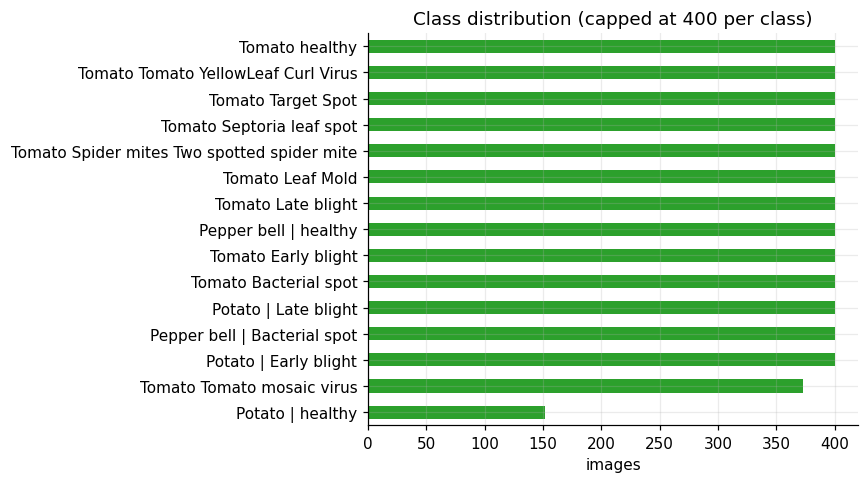

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
counts["total"].sort_values().plot.barh(ax=ax, color="tab:green")
ax.set_xlabel("images"); ax.set_ylabel("")
ax.set_title(f"Class distribution (capped at {CAP_PER_CLASS} per class)")
plt.tight_layout(); plt.savefig(ROOT / "reports" / "fig_class_distribution.png", bbox_inches="tight"); plt.show()

## 2 · Look at the segmentation before trusting it

Every feature except the shape block is computed over **leaf pixels only**. The mask comes from an excess-green-minus-excess-red index, Otsu-thresholded, then reduced to the largest connected component with holes filled.

This is the step that removes PlantVillage's uniform grey background — the single biggest source of the background-memorisation effect that Barbedo (2018) documents. If the masks below look wrong, nothing downstream will work, so inspect them.

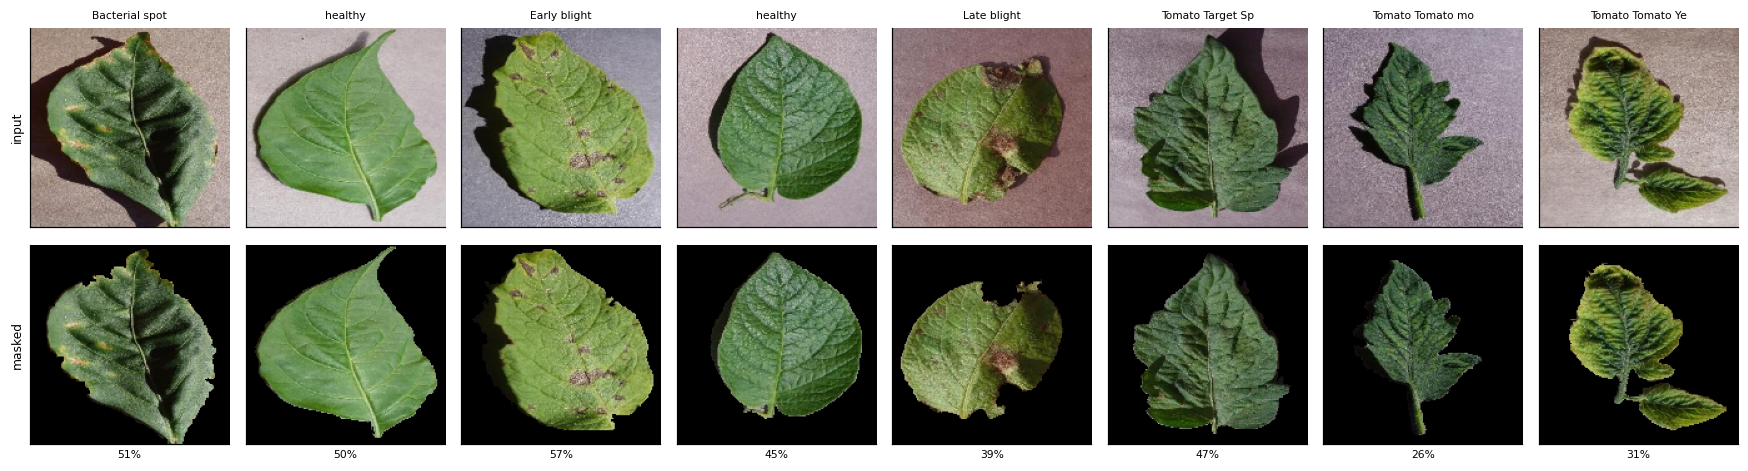

In [5]:
from PIL import Image

sample = manifest.groupby("label", group_keys=False).head(1).head(8)
fig, axes = plt.subplots(2, len(sample), figsize=(2 * len(sample), 4.4))
for k, (_, r) in enumerate(sample.iterrows()):
    with Image.open(r.path) as im:
        arr = np.asarray(im.convert("RGB"), dtype=np.uint8)
    rgb = F.preprocess(arr)
    mask = F.leaf_mask(rgb)
    axes[0, k].imshow(rgb); axes[0, k].set_title(r.label.split("|")[-1].strip()[:16], fontsize=7)
    axes[1, k].imshow(rgb * mask[..., None])
    for a in (axes[0, k], axes[1, k]):
        a.set_xticks([]); a.set_yticks([]); a.grid(False)
    axes[1, k].set_xlabel(f"{mask.mean():.0%}", fontsize=7)
axes[0, 0].set_ylabel("input", fontsize=8); axes[1, 0].set_ylabel("masked", fontsize=8)
plt.tight_layout(); plt.savefig(ROOT / "reports" / "fig_segmentation_samples.png", bbox_inches="tight"); plt.show()

## 3 · Feature extraction

97 features per image, in six blocks (the full contract is in `docs/01_Project_Outline.md` §7):

| Block | Content | Count |
|---|---|---|
| B1 | colour moments — mean, std, skew of R, G, B, H, S, V | 18 |
| B2 | HSV histogram — H×16, S×8, V×8 | 32 |
| B3 | lesion chromaticity — pixel fraction in 6 pathology-relevant HSV boxes, mask coverage, vitality ratio | 8 |
| B4 | GLCM texture — 4 offsets × {contrast, dissimilarity, homogeneity, energy, correlation, entropy} | 24 |
| B5 | uniform LBP histogram, P=8 R=1 | 10 |
| B6 | shape — area fraction, circularity, extent, eccentricity, aspect | 5 |

Every one is written in plain NumPy rather than a library call, because `web/features.js` has to reproduce it exactly. This runs once and is cached to `data/processed/features.npz`.

In [6]:
CACHE = ROOT / "data" / "processed" / "features.npz"
REBUILD = False           # set True after any change to src/features.py

if CACHE.exists() and not REBUILD:
    z = np.load(CACHE, allow_pickle=True)
    X, y, split = z["X"], z["y"], z["split"]
    print(f"loaded cached features: {X.shape}")
else:
    t0 = time.time()
    rows = []
    for i, r in enumerate(manifest.itertuples(), 1):
        rows.append(F.extract_from_path(r.path))
        if i % 250 == 0 or i == len(manifest):
            el = time.time() - t0
            print(f"\r{i}/{len(manifest)}  {el:6.1f}s  eta {el/i*(len(manifest)-i):6.1f}s", end="")
    X = np.asarray(rows, dtype=np.float64)
    y = manifest.label.to_numpy()
    split = manifest.split.to_numpy()
    np.savez_compressed(CACHE, X=X, y=y, split=split)
    print(f"\nextracted {X.shape} in {time.time()-t0:.1f}s -> {CACHE}")

NAMES = F.feature_names()
tr, va, te = split == "train", split == "val", split == "test"
print(f"train {tr.sum()} · val {va.sum()} · test {te.sum()}")
print("non-finite values:", int((~np.isfinite(X)).sum()))

5725/5725   495.7s  eta    0.0s
extracted (5725, 97) in 496.1s -> C:\storage\zee\projects\Karunya\data\processed\features.npz
train 4007 · val 859 · test 859
non-finite values: 0


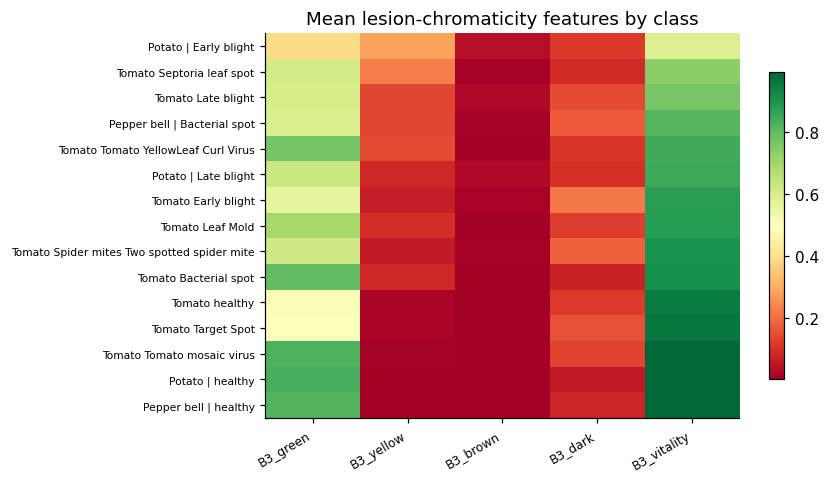

,B3_green,B3_yellow,B3_brown,B3_dark,B3_vitality
label,,,,,
Potato | Early blight,0.392,0.285,0.032,0.115,0.585
Tomato Septoria leaf spot,0.610,0.226,0.005,0.091,0.739
Tomato Late blight,0.601,0.137,0.021,0.146,0.763
Pepper bell | Bacterial spot,0.594,0.139,0.008,0.175,0.817
Tomato Tomato YellowLeaf Curl Virus,0.774,0.146,0.000,0.109,0.842
Potato | Late blight,0.629,0.082,0.023,0.098,0.849
Tomato Early blight,0.563,0.064,0.011,0.220,0.875
Tomato Leaf Mold,0.696,0.096,0.002,0.123,0.877
Tomato Spider mites Two spotted spider mite,0.618,0.058,0.004,0.181,0.906


In [7]:
# Do the lesion-chromaticity features separate the classes at all? A quick sanity check.
feat_df = pd.DataFrame(X, columns=NAMES).assign(label=y)
cols = ["B3_green", "B3_yellow", "B3_brown", "B3_dark", "B3_vitality"]
summary = feat_df.groupby("label")[cols].mean().sort_values("B3_vitality")

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(summary.values, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(len(cols)), cols, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(summary)), summary.index, fontsize=7)
ax.grid(False); plt.colorbar(im, ax=ax, shrink=.8)
ax.set_title("Mean lesion-chromaticity features by class")
plt.tight_layout(); plt.savefig(ROOT / "reports" / "fig_chromaticity_by_class.png", bbox_inches="tight"); plt.show()
summary.round(3)

## 4 · Model comparison

Seven CPU-cheap candidates, all behind the same `StandardScaler`. Selection is done on the **validation** split; the test split is untouched until §6.

In [8]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, top_k_accuracy_score)
from sklearn.inspection import permutation_importance

X_tr, y_tr = X[tr], y[tr]
X_va, y_va = X[va], y[va]
X_te, y_te = X[te], y[te]

CANDIDATES = {
    "Logistic Regression": LogisticRegression(max_iter=4000, C=1.0),
    "Linear SVM":          LinearSVC(C=1.0, max_iter=8000, dual="auto"),
    "RBF SVM":             SVC(C=10, gamma="scale", probability=True, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, min_samples_leaf=1,
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=300, min_samples_leaf=1,
                                                random_state=RANDOM_STATE, n_jobs=-1),
    "Hist Gradient Boost": HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE),
    "k-NN (k=5)":          KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1),
}

rows, fitted = [], {}
for name, est in CANDIDATES.items():
    t0 = time.time()
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", est)]).fit(X_tr, y_tr)
    pred = pipe.predict(X_va)
    rows.append({"model": name,
                 "val_accuracy": accuracy_score(y_va, pred),
                 "val_macro_F1": f1_score(y_va, pred, average="macro"),
                 "fit_seconds": time.time() - t0})
    fitted[name] = pipe
    print(f"{name:<22} macro-F1 {rows[-1]['val_macro_F1']:.4f}   ({rows[-1]['fit_seconds']:.1f}s)")

comparison = pd.DataFrame(rows).sort_values("val_macro_F1", ascending=False).reset_index(drop=True)
comparison.to_csv(ROOT / "reports" / "table_model_comparison.csv", index=False)
comparison.round(4)

Logistic Regression    macro-F1 0.8532   (0.9s)
Linear SVM             macro-F1 0.8509   (2.9s)
RBF SVM                macro-F1 0.8736   (3.5s)
Random Forest          macro-F1 0.8193   (3.8s)
Extra Trees            macro-F1 0.8132   (1.0s)
Hist Gradient Boost    macro-F1 0.8702   (22.1s)
k-NN (k=5)             macro-F1 0.8052   (0.1s)


,model,val_accuracy,val_macro_F1,fit_seconds
0,RBF SVM,0.8754,0.8736,3.4707
1,Hist Gradient Boost,0.8685,0.8702,22.0722
2,Logistic Regression,0.8510,0.8532,0.8583
3,Linear SVM,0.8487,0.8509,2.8621
4,Random Forest,0.8184,0.8193,3.8363
5,Extra Trees,0.8161,0.8132,1.0205
6,k-NN (k=5),0.8091,0.8052,0.1449


### 4.1 Hyper-parameter search on the top two

A randomised search rather than an exhaustive grid: with 97 standardised features the useful region is broad, and the compute is better spent on the ablation in §7.

In [10]:
# ── 4.1 — randomised search with live progress + ETA ──
import time
import numpy as np
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterSampler, cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score

N_ITER          = 12     # candidates sampled per model
CV_FOLDS        = 3
MAX_SECONDS     = 900    # per-model wall-clock budget; stops early, keeps the best so far
EXPORTABLE_ONLY = False  # True = only tune models the browser can actually run (see note below)

EXPORT_KIND = {"Logistic Regression": "linear", "Linear SVM": "linear",
               "Random Forest": "forest", "Extra Trees": "forest"}

def fmt(v):
    if isinstance(v, bool) or v is None:     return v
    if isinstance(v, (int, np.integer)):     return int(v)
    if isinstance(v, (float, np.floating)):  return round(float(v), 5)
    return v

def hms(s):
    s = int(max(s, 0))
    return f"{s//3600}:{(s%3600)//60:02d}:{s%60:02d}" if s >= 3600 else f"{s//60}:{s%60:02d}"

pool = [n for n in comparison.model if not EXPORTABLE_ONLY or n in EXPORT_KIND][:2]
cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
searched = {}

for name in pool:
    # Forests parallelise internally. Asking BOTH the forest and the CV loop for every
    # core oversubscribes the CPU and is often slower than either alone, so pick one.
    probe = clone(CANDIDATES[name])
    inner_parallel = "n_jobs" in probe.get_params()
    cv_jobs = 1 if inner_parallel else -1

    def make(params):
        est = clone(CANDIDATES[name])
        if inner_parallel:
            est.set_params(n_jobs=-1)
        return Pipeline([("scaler", StandardScaler()), ("clf", est)]).set_params(**params)

    cands = list(ParameterSampler(SPACES[name], n_iter=N_ITER, random_state=RANDOM_STATE))
    n_c = len(cands)
    print(f"\n=== {name} — {n_c} candidates x {CV_FOLDS} folds = {n_c*CV_FOLDS} fits "
          f"| budget {hms(MAX_SECONDS)} ===", flush=True)

    t0, times, best_score, best_params = time.time(), [], -np.inf, cands[0]
    for i, params in enumerate(cands, 1):
        tk = time.time()
        score = cross_val_score(make(params), X_tr, y_tr, cv=cv,
                                scoring="f1_macro", n_jobs=cv_jobs).mean()
        times.append(time.time() - tk)
        if score > best_score:
            best_score, best_params = score, params

        elapsed, per = time.time() - t0, float(np.median(times))
        short = {k.replace("clf__", ""): fmt(v) for k, v in params.items()}
        print(f"  [{i:2d}/{n_c}] {times[-1]:6.1f}s  F1 {score:.4f}  best {best_score:.4f}  "
              f"| elapsed {hms(elapsed)}  eta {hms(per*(n_c-i))}  {short}", flush=True)

        if i < n_c and elapsed + per > MAX_SECONDS:
            print(f"  ! {hms(MAX_SECONDS)} budget reached after {i}/{n_c} — keeping the best so far",
                  flush=True)
            break

    final = make(best_params).fit(X_tr, y_tr)
    searched[name] = final
    print(f"{name}: best CV macro-F1 {best_score:.4f}")
    print(f"   { {k: fmt(v) for k, v in best_params.items()} }")
    print(f"   val macro-F1 {f1_score(y_va, final.predict(X_va), average='macro'):.4f}")
    print(f"   total {hms(time.time() - t0)}")


=== RBF SVM — 12 candidates x 3 folds = 36 fits | budget 15:00 ===
  [ 1/12]    7.2s  F1 0.6650  best 0.6650  | elapsed 0:07  eta 1:19  {'gamma': 0.18738, 'C': 187.38174}
  [ 2/12]    7.1s  F1 0.7347  best 0.7347  | elapsed 0:14  eta 1:11  {'gamma': 0.03511, 'C': 0.23101}
  [ 3/12]    9.3s  F1 0.4323  best 0.7347  | elapsed 0:23  eta 1:04  {'gamma': 0.43288, 'C': 15.19911}
  [ 4/12]    5.4s  F1 0.8389  best 0.8389  | elapsed 0:29  eta 0:57  {'gamma': 0.00023, 'C': 81.11308}
  [ 5/12]    5.6s  F1 0.7815  best 0.8389  | elapsed 0:34  eta 0:49  {'gamma': 0.08111, 'C': 2.84804}
  [ 6/12]    5.1s  F1 0.2225  best 0.8389  | elapsed 0:39  eta 0:38  {'gamma': 0.0001, 'C': 0.23101}
  [ 7/12]    1.7s  F1 0.8592  best 0.8592  | elapsed 0:41  eta 0:27  {'gamma': 0.0001, 'C': 1000.0}
  [ 8/12]    1.8s  F1 0.8746  best 0.8746  | elapsed 0:43  eta 0:21  {'gamma': 0.00658, 'C': 6.57933}
  [ 9/12]    2.3s  F1 0.8672  best 0.8746  | elapsed 0:45  eta 0:16  {'gamma': 0.0152, 'C': 6.57933}
  [10/12]    3

## 5 · Choose the model to deploy

Two constraints decide this, not accuracy alone:

1. It must serialise to the JSON format `web/inference.js` evaluates — a **linear** model (coefficient matrix, a few kB) or a **tree ensemble** (flat arrays, a few hundred kB). An RBF SVM only qualifies if its support-vector count stays small.
2. It must fit in a web page. If the accuracy gap between the best model and the best *exportable* model is small, take the exportable one and report the trade-off.

In [11]:
EXPORT_KIND = {"Logistic Regression": "linear", "Linear SVM": "linear",
               "Random Forest": "forest", "Extra Trees": "forest"}

ranked = [(n, f1_score(y_va, m.predict(X_va), average="macro"))
          for n, m in {**fitted, **searched}.items()]
ranked.sort(key=lambda t: -t[1])
print("validation ranking:")
for n, s in ranked:
    tag = EXPORT_KIND.get(n, "NOT EXPORTABLE")
    print(f"  {n:<22} {s:.4f}   [{tag}]")

BEST_NAME = next(n for n, _ in ranked if n in EXPORT_KIND)
best_model = searched.get(BEST_NAME, fitted[BEST_NAME])
KIND = EXPORT_KIND[BEST_NAME]
print(f"\ndeploying: {BEST_NAME}  (export kind: {KIND})")
if ranked[0][0] != BEST_NAME:
    print(f"note: {ranked[0][0]} scored {ranked[0][1]:.4f} but is not exportable to the browser; "
          f"the accuracy cost of that constraint is {ranked[0][1] - dict(ranked)[BEST_NAME]:.4f} macro-F1.")

validation ranking:
  RBF SVM                0.8768   [NOT EXPORTABLE]
  Hist Gradient Boost    0.8732   [NOT EXPORTABLE]
  Logistic Regression    0.8532   [linear]
  Linear SVM             0.8509   [linear]
  Random Forest          0.8193   [forest]
  Extra Trees            0.8132   [forest]
  k-NN (k=5)             0.8052   [NOT EXPORTABLE]

deploying: Logistic Regression  (export kind: linear)
note: RBF SVM scored 0.8768 but is not exportable to the browser; the accuracy cost of that constraint is 0.0236 macro-F1.


## 6 · Final evaluation on the held-out test split

Reported once, on data no model-selection decision has touched.

In [12]:
# clone() everywhere an estimator is reused: Pipeline holds a reference, not a copy,
# so refitting one on a feature subset (as the ablation does) would corrupt the others.
final = Pipeline([("scaler", StandardScaler()),
                  ("clf", clone(best_model.named_steps["clf"]))]).fit(
                      np.vstack([X_tr, X_va]), np.concatenate([y_tr, y_va]))
y_pred = final.predict(X_te)
labels = sorted(np.unique(y))

acc = accuracy_score(y_te, y_pred)
mf1 = f1_score(y_te, y_pred, average="macro")
print(f"accuracy    {acc:.4f}")
print(f"macro-F1    {mf1:.4f}")
if hasattr(final, "predict_proba"):
    print(f"top-3 acc.  {top_k_accuracy_score(y_te, final.predict_proba(X_te), k=3, labels=final.classes_):.4f}")
print()
print(classification_report(y_te, y_pred, digits=3))

accuracy    0.8673
macro-F1    0.8666
top-3 acc.  0.9767

                                             precision    recall  f1-score   support

               Pepper bell | Bacterial spot      0.933     0.933     0.933        60
                      Pepper bell | healthy      0.952     0.983     0.967        60
                      Potato | Early blight      0.905     0.950     0.927        60
                       Potato | Late blight      0.797     0.917     0.853        60
                           Potato | healthy      0.905     0.826     0.864        23
                      Tomato Bacterial spot      0.895     0.850     0.872        60
                        Tomato Early blight      0.765     0.650     0.703        60
                         Tomato Late blight      0.746     0.733     0.739        60
                           Tomato Leaf Mold      0.772     0.733     0.752        60
                  Tomato Septoria leaf spot      0.820     0.833     0.826        60
Tomato

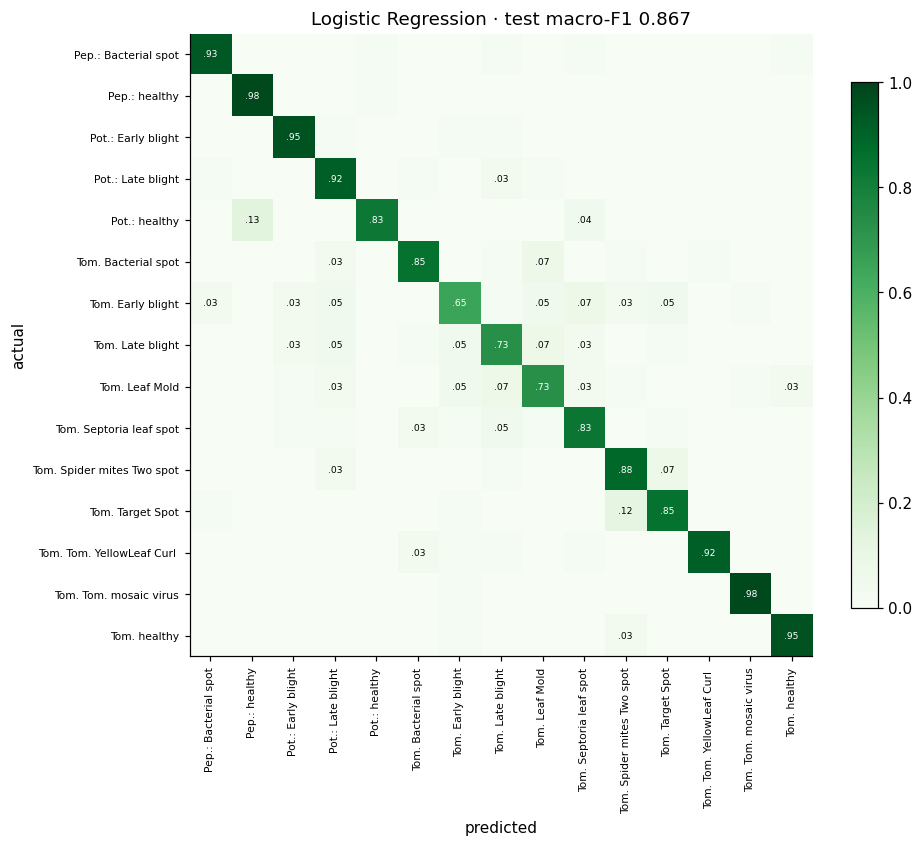

,actual,predicted,rate
0,Potato | healthy,Pepper bell | healthy,0.130
1,Tomato Target Spot,Tomato Spider mites Two spotted spider mite,0.117
2,Tomato Bacterial spot,Tomato Leaf Mold,0.067
3,Tomato Early blight,Tomato Septoria leaf spot,0.067
4,Tomato Late blight,Tomato Leaf Mold,0.067
5,Tomato Leaf Mold,Tomato Late blight,0.067
6,Tomato Spider mites Two spotted spider mite,Tomato Target Spot,0.067
7,Tomato Early blight,Potato | Late blight,0.050
8,Tomato Early blight,Tomato Leaf Mold,0.050
9,Tomato Early blight,Tomato Target Spot,0.050


In [13]:
cm = confusion_matrix(y_te, y_pred, labels=labels, normalize="true")
short = [l.replace("Tomato", "Tom.").replace("Pepper bell", "Pep.").replace("Potato", "Pot.")
          .replace(" | ", ": ")[:26] for l in labels]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), short, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels)), short, fontsize=7)
for i in range(len(labels)):
    for j in range(len(labels)):
        if cm[i, j] > 0.02:
            ax.text(j, i, f"{cm[i, j]:.2f}".lstrip("0"), ha="center", va="center", fontsize=6,
                    color="white" if cm[i, j] > .55 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.grid(False)
ax.set_title(f"{BEST_NAME} · test macro-F1 {mf1:.3f}")
plt.colorbar(im, ax=ax, shrink=.75)
plt.tight_layout(); plt.savefig(ROOT / "reports" / "fig_confusion_matrix.png", bbox_inches="tight"); plt.show()

# Which pairs actually get confused? This is the paragraph the report needs.
off = [(labels[i], labels[j], cm[i, j]) for i in range(len(labels))
       for j in range(len(labels)) if i != j and cm[i, j] >= 0.03]
pd.DataFrame(sorted(off, key=lambda t: -t[2]), columns=["actual", "predicted", "rate"]).head(12).round(3)

In [14]:
cv = cross_val_score(Pipeline([("scaler", StandardScaler()), ("clf", clone(best_model.named_steps["clf"]))]),
                     X, y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                     scoring="f1_macro", n_jobs=-1)
print(f"5-fold CV macro-F1: {cv.mean():.4f} ± {cv.std():.4f}   {np.round(cv, 4)}")

5-fold CV macro-F1: 0.8643 ± 0.0096   [0.8602 0.8701 0.8478 0.8757 0.8676]


## 7 · Ablation — does every feature block earn its place?

Drop one block at a time and re-measure. A block whose removal costs nothing is dead weight in a model that has to fit in a web page.

In [15]:
BLOCKS = {b: [i for i, n in enumerate(NAMES) if n.startswith(b)] for b in
          ["B1", "B2", "B3", "B4", "B5", "B6"]}
BLOCK_NAMES = {"B1": "colour moments", "B2": "HSV histogram", "B3": "lesion chromaticity",
               "B4": "GLCM texture", "B5": "uniform LBP", "B6": "shape"}

def score_subset(idx):
    p = Pipeline([("scaler", StandardScaler()), ("clf", clone(best_model.named_steps["clf"]))])
    p.fit(X_tr[:, idx], y_tr)
    return f1_score(y_va, p.predict(X_va[:, idx]), average="macro")

full_idx = list(range(len(NAMES)))
full_score = score_subset(full_idx)
abl = [{"configuration": "all 97 features", "n_features": len(NAMES),
        "macro_F1": full_score, "delta": 0.0}]
for b, idx in BLOCKS.items():
    keep = [i for i in full_idx if i not in idx]
    s = score_subset(keep)
    abl.append({"configuration": f"without {b} ({BLOCK_NAMES[b]})", "n_features": len(keep),
                "macro_F1": s, "delta": s - full_score})
for b, idx in BLOCKS.items():
    s = score_subset(idx)
    abl.append({"configuration": f"{b} only ({BLOCK_NAMES[b]})", "n_features": len(idx),
                "macro_F1": s, "delta": s - full_score})

ablation = pd.DataFrame(abl)
ablation.to_csv(ROOT / "reports" / "table_ablation.csv", index=False)
ablation.round(4)

,configuration,n_features,macro_F1,delta
0,all 97 features,97,0.8532,0.0000
1,without B1 (colour moments),79,0.8330,-0.0202
2,without B2 (HSV histogram),65,0.8276,-0.0256
3,without B3 (lesion chromaticity),89,0.8453,-0.0079
4,without B4 (GLCM texture),73,0.8308,-0.0224
5,without B5 (uniform LBP),87,0.8331,-0.0201
6,without B6 (shape),92,0.8495,-0.0036
7,B1 only (colour moments),18,0.6150,-0.2381
8,B2 only (HSV histogram),32,0.5890,-0.2641
9,B3 only (lesion chromaticity),8,0.4050,-0.4482


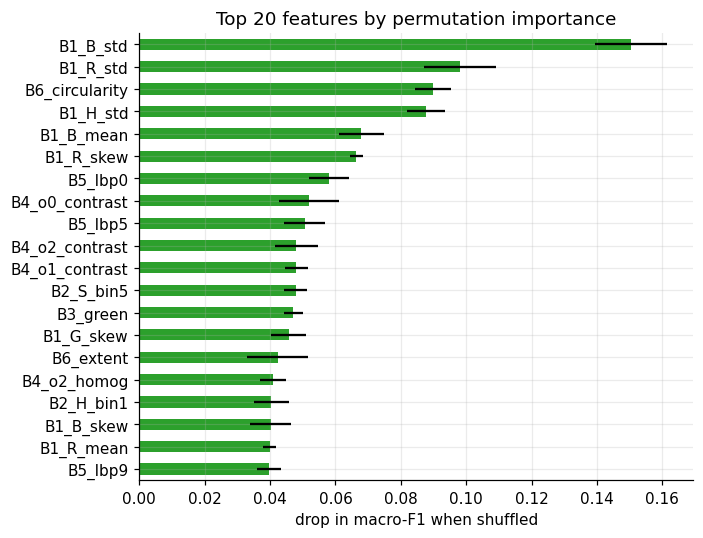

B1_B_std          0.1503
B1_R_std          0.0982
B6_circularity    0.0899
B1_H_std          0.0877
B1_B_mean         0.0679
B1_R_skew         0.0664
B5_lbp0           0.0579
B4_o0_contrast    0.0519
B5_lbp5           0.0506
B4_o2_contrast    0.0481
B4_o1_contrast    0.0480
B2_S_bin5         0.0478
B3_green          0.0471
B1_G_skew         0.0457
B6_extent         0.0423
B4_o2_homog       0.0409
B2_H_bin1         0.0404
B1_B_skew         0.0402
B1_R_mean         0.0399
B5_lbp9           0.0397
dtype: float64

In [16]:
pi = permutation_importance(final, X_te, y_te, n_repeats=5, random_state=RANDOM_STATE,
                            scoring="f1_macro", n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=NAMES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6.5, 5))
imp.head(20)[::-1].plot.barh(ax=ax, color="tab:green",
                             xerr=pd.Series(pi.importances_std, index=NAMES)[imp.head(20).index][::-1])
ax.set_xlabel("drop in macro-F1 when shuffled")
ax.set_title("Top 20 features by permutation importance")
plt.tight_layout(); plt.savefig(ROOT / "reports" / "fig_permutation_importance.png", bbox_inches="tight"); plt.show()
imp.head(20).round(4)

## 8 · Fit the deployment budget

A fully-grown 500-tree Extra Trees model exports to **tens of megabytes** of JSON. That is not a model anyone will download over a rural connection, and it defeats the whole point of choosing classical ML.

So the deployment budget is a real model-selection constraint, not an afterthought. The cell below compacts the chosen model — fewer trees, shallower, larger leaves — until the exported JSON fits `MAX_MODEL_KB`, and reports exactly what that costs in accuracy. If no tree configuration fits, it falls back to the best linear model, which exports in a couple of kilobytes.

**This trade-off curve is a result worth putting in the report**: it is the quantitative answer to "why not just use the biggest model?".

In [18]:
MAX_MODEL_KB = 1500          # what a page can reasonably carry

def export_size_kb(model, kind):
    import tempfile
    with tempfile.NamedTemporaryFile(suffix=".json", delete=False) as f:
        EX.export_model(model, list(model.classes_), kind, meta={}, path=f.name)
        kb = os.path.getsize(f.name) / 1024
    os.unlink(f.name)
    return kb

X_full = np.vstack([X_tr, X_va]); y_full = np.concatenate([y_tr, y_va])
budget_rows = []

if KIND == "forest":
    base_clf = best_model.named_steps["clf"]
    LADDER = [dict(n_estimators=n, min_samples_leaf=m, max_depth=d)
              for n, m, d in [(300, 1, None), (200, 2, None), (150, 4, 24),
                              (100, 6, 20), (60, 8, 16), (40, 12, 14)]]
    chosen = None
    for params in LADDER:
        cand = Pipeline([("scaler", StandardScaler()),
                         ("clf", clone(base_clf).set_params(**params))]).fit(X_full, y_full)
        kb = export_size_kb(cand, "forest")
        f1v = f1_score(y_te, cand.predict(X_te), average="macro")
        budget_rows.append({**params, "size_kB": round(kb, 1), "test_macro_F1": round(f1v, 4)})
        print(f"  {str(params):<58} {kb:8.1f} kB   macro-F1 {f1v:.4f}")
        if chosen is None and kb <= MAX_MODEL_KB:
            chosen = (cand, kb, f1v, params)
    if chosen is None:
        print(f"\nNo tree configuration fits {MAX_MODEL_KB} kB - falling back to a linear model.")
        lin_name = next(n for n, _ in ranked if EXPORT_KIND.get(n) == "linear")
        final = Pipeline([("scaler", StandardScaler()),
                          ("clf", clone({**fitted, **searched}[lin_name].named_steps["clf"]))]).fit(X_full, y_full)
        KIND, BEST_NAME = "linear", lin_name
    else:
        final, kb, f1v, params = chosen
        print(f"\nselected {params} at {kb:.1f} kB (macro-F1 {f1v:.4f})")
else:
    print("linear model - export size is a few kB, no compaction needed")

if budget_rows:
    budget = pd.DataFrame(budget_rows)
    budget.to_csv(ROOT / "reports" / "table_size_budget.csv", index=False)
    display(budget)

y_pred = final.predict(X_te)
acc = accuracy_score(y_te, y_pred)
mf1 = f1_score(y_te, y_pred, average="macro")
print(f"\nDEPLOYED MODEL: {BEST_NAME} ({KIND})   test accuracy {acc:.4f}   macro-F1 {mf1:.4f}")

linear model - export size is a few kB, no compaction needed

DEPLOYED MODEL: Logistic Regression (linear)   test accuracy 0.8673   macro-F1 0.8666


## 9 · Export to the browser

Two gates before this model is allowed to ship:

1. **Export fidelity** — the JSON evaluator must reproduce scikit-learn's predictions.
2. **Feature parity** — `web/features.js` must reproduce `src/features.py`. Without this the browser computes a different vector from the one the model was trained on, and every prediction is quietly wrong.

In [19]:
meta = {
    "features": NAMES,
    "n_features": len(NAMES),
    "model": BEST_NAME,
    "test_accuracy": round(float(acc), 4),
    "test_macro_f1": round(float(mf1), 4),
    "cv_macro_f1_mean": round(float(cv.mean()), 4),
    "cv_macro_f1_std": round(float(cv.std()), 4),
    "n_train_images": int(tr.sum() + va.sum()),
    "cap_per_class": CAP_PER_CLASS,
    "dataset": "PlantVillage 3-crop subset (tomato, potato, bell pepper)",
    "caveat": "Trained on laboratory-condition imagery; accuracy on field photographs is lower.",
}
out_path = ROOT / "web" / "models" / "disease_model.json"
doc = EX.export_model(final, list(final.classes_), KIND, meta=meta, path=out_path)

if KIND == "linear":
    ref = final.decision_function(X_te)
    got = EX.predict_json(doc, X_te)
    agree = (np.argmax(got, axis=1) == np.argmax(np.atleast_2d(ref), axis=1)).mean()
else:
    got = EX.predict_json(doc, X_te)
    agree = (np.array(list(final.classes_))[np.argmax(got, axis=1)] == final.predict(X_te)).mean()
print(f"exported {out_path.name}  ({out_path.stat().st_size/1024:.1f} kB)")
print(f"JSON evaluator agrees with scikit-learn on {agree:.4%} of test predictions")
assert agree > 0.999, "export mismatch - do not deploy"

exported disease_model.json  (22.2 kB)
JSON evaluator agrees with scikit-learn on 100.0000% of test predictions


In [20]:
import subprocess
r = subprocess.run([sys.executable, str(ROOT / "src" / "parity_test.py")],
                   capture_output=True, text=True, cwd=str(ROOT))
print(r.stdout[-1200:] or r.stderr[-1200:])
assert r.returncode == 0, "PYTHON/JS FEATURE PARITY FAILED - browser predictions would be wrong"

{
  "n_images": 4,
  "sources": [
    "synthetic_0",
    "synthetic_1",
    "synthetic_2",
    "synthetic_3"
  ],
  "max_abs_diff": 2.291515935337607e-12,
  "max_rel_diff": 2.291515935337607e-12,
  "worst_feature": "B1_B_skew",
  "worst_feature_rel_diff": 2.291515935337607e-12,
  "tolerance": 0.0001,
  "passed": true
}

PARITY OK - browser inference will match the notebook.



### Try it

```bash
cd web && python -m http.server 8000
```

Then open <http://localhost:8000>. Drop a leaf photo into tab 1, set the field
inputs in tab 2, and read the fused advisory in tab 3. Everything runs in the
browser; switch the network off and it still works.

## 10 · What to write in the report

| Claim | Evidence in this notebook |
|---|---|
| Classical features are competitive on this benchmark | §4 comparison table, §6 test metrics |
| Every feature block earns its place | §7 ablation table |
| The model is interpretable | §7 permutation importance, plus the live per-feature contributions in the web app |
| It is deployable where it matters | §8 model size in kB, browser inference latency shown in the app |
| It is reproducible | committed manifest, fixed seeds, cached features, parity test |

**Do not lead with the accuracy figure.** Every paper in the literature already reports 99% on this dataset. Lead with the operating point: this accuracy, at this model size, with no server and no network — and with the field gap measured rather than assumed.